# Task 2: 2D U-Net for BraTS Multi-modal MRI Segmentation

This notebook trains a baseline 2D U-Net for glioma segmentation using preprocessed BraTS 2D slices.

Input:

```python
image.shape = [4, 192, 208]
Label:

label.shape = [3, 192, 208]
The three label channels are assumed to be:

channel 0: WT, Whole Tumor
channel 1: TC, Tumor Core
channel 2: ET, Enhancing Tumor
Because WT, TC and ET are nested regions, this is treated as a multi-label segmentation task.

Therefore, the model uses:

sigmoid activation
Dice Loss + BCEWithLogitsLoss

1. Imports
This cell imports all required packages.

In [19]:
import os
import csv
import math
import random
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

PyTorch version: 2.4.1
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Configuration

This is the main configuration cell.

Modify this cell if you want to change:

- data path
- batch size
- epoch number
- learning rate
- output directory
- data augmentation
- visualization frequency

In [20]:
# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path(r"D:\Imaging\project2\processed_slices")

OUTPUT_DIR = Path("outputs_task2_unet2d")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_KEY = "image"
LABEL_KEY = "label"

IN_CHANNELS = 4
OUT_CHANNELS = 3

IMAGE_HEIGHT = 192
IMAGE_WIDTH = 208

REGION_NAMES = ["WT", "TC", "ET"]

VAL_RATIO = 0.2
RANDOM_SEED = 42

BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# For Windows + Jupyter, NUM_WORKERS = 0 is the safest option.
NUM_WORKERS = 0

USE_AUGMENTATION = True
USE_AMP = True

THRESHOLD = 0.5
VIS_EVERY_N_EPOCHS = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("DEVICE:", DEVICE)

DATA_ROOT: D:\Imaging\project2\processed_slices
OUTPUT_DIR: D:\Imaging\project2\outputs_task2_unet2d
DEVICE: cuda


## 3. Reproducibility

This cell fixes random seeds for Python, NumPy and PyTorch.

In [21]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(RANDOM_SEED)

## 4. Scan Dataset and Patient-level Split

This cell scans all `.npz` files under `processed_slices`.

The split is performed at patient level, not slice level.

This avoids data leakage because slices from the same patient should not appear in both training and validation sets.

In [22]:
def scan_dataset(data_root):
    data_root = Path(data_root)

    if not data_root.exists():
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")

    all_npz_files = sorted(data_root.glob("*/*.npz"))

    case_to_files = defaultdict(list)

    for path in all_npz_files:
        case_id = path.parent.name
        case_to_files[case_id].append(path)

    case_ids = sorted(case_to_files.keys())

    print("Number of cases:", len(case_ids))
    print("Number of slices:", len(all_npz_files))

    counts = [len(case_to_files[c]) for c in case_ids]

    print("Slices per case:")
    print("  min   :", min(counts))
    print("  max   :", max(counts))
    print("  mean  :", float(np.mean(counts)))
    print("  median:", float(np.median(counts)))

    return case_to_files, case_ids


case_to_files, case_ids = scan_dataset(DATA_ROOT)

rng = random.Random(RANDOM_SEED)
shuffled_cases = case_ids.copy()
rng.shuffle(shuffled_cases)

num_val = int(round(len(shuffled_cases) * VAL_RATIO))

val_cases = sorted(shuffled_cases[:num_val])
train_cases = sorted(shuffled_cases[num_val:])

train_files = []
val_files = []

for case_id in train_cases:
    train_files.extend(case_to_files[case_id])

for case_id in val_cases:
    val_files.extend(case_to_files[case_id])

train_files = sorted(train_files)
val_files = sorted(val_files)

print()
print("Train cases:", len(train_cases))
print("Val cases  :", len(val_cases))
print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))

with open(OUTPUT_DIR / "train_cases.txt", "w", encoding="utf-8") as f:
    for case_id in train_cases:
        f.write(case_id + "\n")

with open(OUTPUT_DIR / "val_cases.txt", "w", encoding="utf-8") as f:
    for case_id in val_cases:
        f.write(case_id + "\n")

Number of cases: 595
Number of slices: 38976
Slices per case:
  min   : 25
  max   : 109
  mean  : 65.50588235294117
  median: 66.0

Train cases: 476
Val cases  : 119
Train slices: 31227
Val slices  : 7749


## 5. Quick Data Sanity Check

This cell reads one `.npz` sample and checks:

- keys
- image shape
- label shape
- label values
- case ID
- slice index
- modality order
- label order

In [23]:
def read_npz_value(x):
    if isinstance(x, np.ndarray):
        if x.shape == ():
            return x.item()
        return x.tolist()

    return x


def inspect_npz(path):
    with np.load(path, allow_pickle=True) as data:
        print("File:", path)
        print("Keys:", list(data.files))

        image = data[IMAGE_KEY]
        label = data[LABEL_KEY]

        print("image shape:", image.shape, image.dtype)
        print("label shape:", label.shape, label.dtype)
        print("label unique:", np.unique(label))

        if "case_id" in data:
            print("case_id:", read_npz_value(data["case_id"]))

        if "slice_idx" in data:
            print("slice_idx:", read_npz_value(data["slice_idx"]))

        if "modality_order" in data:
            print("modality_order:", read_npz_value(data["modality_order"]))

        if "label_order" in data:
            print("label_order:", read_npz_value(data["label_order"]))


inspect_npz(train_files[0])

File: D:\Imaging\project2\processed_slices\BraTS-GLI-00000-000\BraTS-GLI-00000-000_slice_045.npz
Keys: ['image', 'label', 'case_id', 'slice_idx', 'original_shape', 'cropped_shape', 'padded_shape', 'target_h', 'target_w', 'image_padding_values', 'modality_order', 'label_order']
image shape: (4, 192, 208) float32
label shape: (3, 192, 208) uint8
label unique: [0 1]
case_id: BraTS-GLI-00000-000
slice_idx: 45
modality_order: ['T1', 'T1ce', 'T2', 'FLAIR']
label_order: ['WT', 'TC', 'ET']


## 6. Core Component: Dataset and Data Augmentation

This is one of the core cells.

The dataset returns:

```python
image: [4, 192, 208]
label: [3, 192, 208]
Data augmentation includes:

random horizontal flip
random vertical flip
random affine transformation
Gaussian noise
Important:

image uses bilinear interpolation
label uses nearest-neighbor interpolation
label remains binary after augmentation

In [24]:
def random_affine_torch(image, label, max_angle=10.0, scale_range=(0.9, 1.1), p=0.5):
    if random.random() > p:
        return image, label

    angle = random.uniform(-max_angle, max_angle) * math.pi / 180.0
    scale = random.uniform(scale_range[0], scale_range[1])

    cos_a = math.cos(angle) / scale
    sin_a = math.sin(angle) / scale

    theta = torch.tensor(
        [
            [cos_a, -sin_a, 0.0],
            [sin_a, cos_a, 0.0],
        ],
        dtype=image.dtype,
        device=image.device,
    )

    theta = theta.unsqueeze(0)

    image_4d = image.unsqueeze(0)
    label_4d = label.unsqueeze(0)

    grid = F.affine_grid(
        theta,
        image_4d.size(),
        align_corners=False,
    )

    image_aug = F.grid_sample(
        image_4d,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=False,
    )

    label_aug = F.grid_sample(
        label_4d,
        grid,
        mode="nearest",
        padding_mode="zeros",
        align_corners=False,
    )

    image_aug = image_aug.squeeze(0)
    label_aug = label_aug.squeeze(0)

    label_aug = (label_aug > 0.5).float()

    return image_aug, label_aug


def apply_augmentation(image, label):
    if random.random() < 0.5:
        image = torch.flip(image, dims=[2])
        label = torch.flip(label, dims=[2])

    if random.random() < 0.5:
        image = torch.flip(image, dims=[1])
        label = torch.flip(label, dims=[1])

    image, label = random_affine_torch(
        image,
        label,
        max_angle=10.0,
        scale_range=(0.9, 1.1),
        p=0.5,
    )

    if random.random() < 0.3:
        noise_std = random.uniform(0.0, 0.05)
        image = image + noise_std * torch.randn_like(image)

    return image, label


class BraTSSliceDataset(Dataset):
    def __init__(self, files, augment=False):
        self.files = list(files)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]

        with np.load(path, allow_pickle=True) as data:
            image = data[IMAGE_KEY].astype(np.float32)
            label = data[LABEL_KEY].astype(np.float32)

            if "case_id" in data:
                case_id = read_npz_value(data["case_id"])
            else:
                case_id = path.parent.name

            if "slice_idx" in data:
                slice_idx = int(read_npz_value(data["slice_idx"]))
            else:
                slice_idx = -1

        expected_image_shape = (IN_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)
        expected_label_shape = (OUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)

        if image.shape != expected_image_shape:
            raise ValueError(f"Unexpected image shape {image.shape} in {path}")

        if label.shape != expected_label_shape:
            raise ValueError(f"Unexpected label shape {label.shape} in {path}")

        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()

        if self.augment:
            image, label = apply_augmentation(image, label)

        sample = {
            "image": image,
            "label": label,
            "case_id": str(case_id),
            "slice_idx": int(slice_idx),
            "path": str(path),
        }

        return sample


train_dataset = BraTSSliceDataset(train_files, augment=USE_AUGMENTATION)
val_dataset = BraTSSliceDataset(val_files, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

batch = next(iter(train_loader))

print("Batch image:", batch["image"].shape, batch["image"].dtype)
print("Batch label:", batch["label"].shape, batch["label"].dtype)
print("Example case_id:", batch["case_id"][0])
print("Example slice_idx:", batch["slice_idx"][0])

Batch image: torch.Size([8, 4, 192, 208]) torch.float32
Batch label: torch.Size([8, 3, 192, 208]) torch.float32
Example case_id: BraTS-GLI-00271-000
Example slice_idx: tensor(92)


## 7. Visualize Training Sample

This cell visualizes one image slice and its WT / TC / ET masks.

If modality order is `[T1, T1ce, T2, FLAIR]`, then channel 3 is FLAIR.

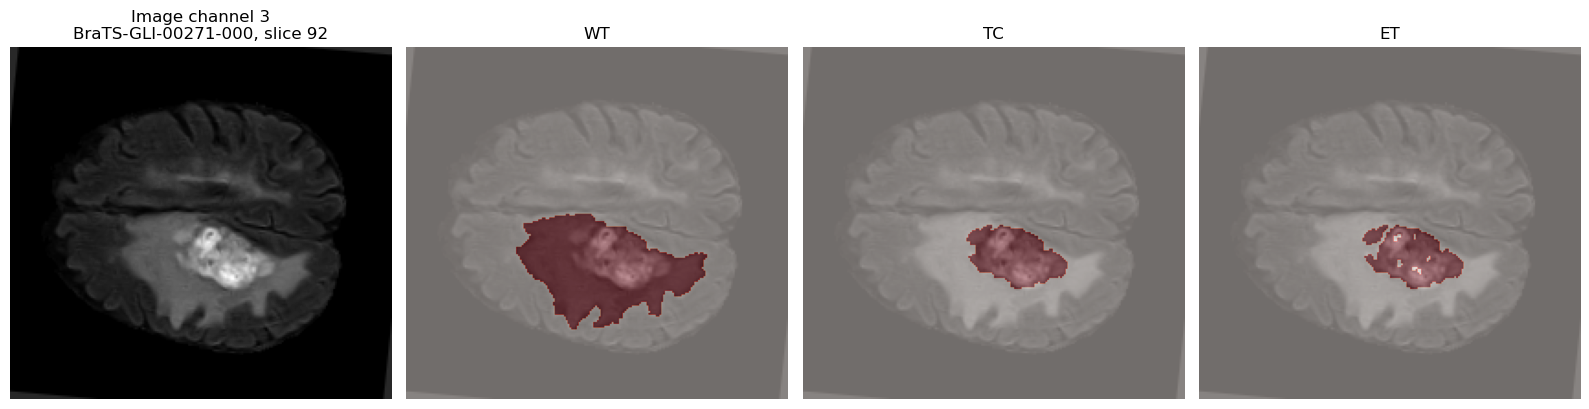

In [25]:
def show_sample_from_batch(batch, index=0, image_channel=3):
    image = batch["image"][index].numpy()
    label = batch["label"][index].numpy()

    case_id = batch["case_id"][index]
    slice_idx = batch["slice_idx"][index]

    if torch.is_tensor(slice_idx):
        slice_idx = slice_idx.item()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(image[image_channel], cmap="gray")
    axes[0].set_title(f"Image channel {image_channel}\n{case_id}, slice {slice_idx}")
    axes[0].axis("off")

    for i, name in enumerate(REGION_NAMES):
        axes[i + 1].imshow(image[image_channel], cmap="gray")
        axes[i + 1].imshow(label[i], cmap="Reds", alpha=0.45)
        axes[i + 1].set_title(name)
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_from_batch(batch, index=0, image_channel=3)

## 8. Core Component: U-Net Network Architecture

This is the main model definition cell.

Input:

```python
[B, 4, 192, 208]
Output logits:

[B, 3, 192, 208]
The final layer does not use sigmoid.

Sigmoid is applied inside the loss function and during validation.

In [26]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True,
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2,
            ],
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=4, out_channels=3, base_channels=32):
        super().__init__()

        self.in_conv = DoubleConv(in_channels, base_channels)

        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = Up(base_channels * 16 + base_channels * 8, base_channels * 8)
        self.up2 = Up(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.up3 = Up(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.up4 = Up(base_channels * 2 + base_channels, base_channels)

        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.out_conv(x)

        return logits


model = UNet2D(
    in_channels=IN_CHANNELS,
    out_channels=OUT_CHANNELS,
    base_channels=32,
).to(DEVICE)

x_test = torch.randn(
    2,
    IN_CHANNELS,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
).to(DEVICE)

with torch.no_grad():
    y_test = model(x_test)

print("Input shape:", x_test.shape)
print("Output shape:", y_test.shape)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")

Input shape: torch.Size([2, 4, 192, 208])
Output shape: torch.Size([2, 3, 192, 208])
Total parameters: 7,849,955
Trainable parameters: 7,849,955


## 9. Core Component: Dice Loss and Hybrid Loss

This cell defines the loss function.

The final loss is:

```python
Loss = DiceLoss + BCEWithLogitsLoss
This is suitable for class-imbalanced multi-label medical image segmentation.

The model outputs logits, not probabilities.

In [27]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        dims = (0, 2, 3)

        intersection = torch.sum(probs * targets, dim=dims)
        denominator = torch.sum(probs, dim=dims) + torch.sum(targets, dim=dims)

        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )

        loss = 1.0 - dice

        return loss.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()

        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        dice = self.dice_loss(logits, targets)
        bce = self.bce_loss(logits, targets)

        total = self.dice_weight * dice + self.bce_weight * bce

        loss_parts = {
            "dice_loss": float(dice.detach().cpu()),
            "bce_loss": float(bce.detach().cpu()),
        }

        return total, loss_parts


criterion = DiceBCELoss(
    dice_weight=1.0,
    bce_weight=1.0,
).to(DEVICE)

print(criterion)

DiceBCELoss(
  (dice_loss): DiceLoss()
  (bce_loss): BCEWithLogitsLoss()
)


## 10. Core Component: Dice Metric

This cell computes validation Dice for:

- WT
- TC
- ET
- Mean Dice

Prediction is obtained by:

```python
prob = sigmoid(logits)
pred = prob > threshold

In [28]:
class DiceAccumulator:
    def __init__(self, num_channels=3, threshold=0.5, smooth=1e-5):
        self.num_channels = num_channels
        self.threshold = threshold
        self.smooth = smooth

        self.intersection = torch.zeros(num_channels, dtype=torch.float64)
        self.pred_sum = torch.zeros(num_channels, dtype=torch.float64)
        self.target_sum = torch.zeros(num_channels, dtype=torch.float64)

    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).float()
        targets = targets.float()

        dims = (0, 2, 3)

        intersection = torch.sum(preds * targets, dim=dims)
        pred_sum = torch.sum(preds, dim=dims)
        target_sum = torch.sum(targets, dim=dims)

        self.intersection += intersection.detach().cpu().double()
        self.pred_sum += pred_sum.detach().cpu().double()
        self.target_sum += target_sum.detach().cpu().double()

    def compute(self):
        dice = (2.0 * self.intersection + self.smooth) / (
            self.pred_sum + self.target_sum + self.smooth
        )

        return dice.numpy()

## 11. Optimizer and Scheduler

This cell defines:

- AdamW optimizer
- ReduceLROnPlateau scheduler
- AMP GradScaler

In [29]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

scaler = torch.cuda.amp.GradScaler(
    enabled=(USE_AMP and DEVICE.type == "cuda")
)


def get_current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


C:\Users\27871\AppData\Local\Temp\ipykernel_5384\673542364.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


## 12. Core Component: Training and Validation Loops

This cell defines:

- `train_one_epoch`
- `validate_one_epoch`

This is the main training logic.

In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None and scaler.is_enabled():
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss, loss_parts = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(images)
            loss, loss_parts = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
                "lr": get_current_lr(optimizer),
            }
        )

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
    }

    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice_loss = 0.0
    running_bce_loss = 0.0
    num_samples = 0

    dice_acc = DiceAccumulator(
        num_channels=OUT_CHANNELS,
        threshold=threshold,
    )

    pbar = tqdm(loader, desc="Val", leave=False)

    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        batch_size = images.size(0)

        logits = model(images)
        loss, loss_parts = criterion(logits, labels)

        running_loss += loss.item() * batch_size
        running_dice_loss += loss_parts["dice_loss"] * batch_size
        running_bce_loss += loss_parts["bce_loss"] * batch_size
        num_samples += batch_size

        dice_acc.update(logits, labels)

        pbar.set_postfix(
            {
                "loss": running_loss / max(num_samples, 1),
            }
        )

    dice_values = dice_acc.compute()

    metrics = {
        "loss": running_loss / num_samples,
        "dice_loss": running_dice_loss / num_samples,
        "bce_loss": running_bce_loss / num_samples,
        "dice_wt": float(dice_values[0]),
        "dice_tc": float(dice_values[1]),
        "dice_et": float(dice_values[2]),
        "mean_dice": float(np.mean(dice_values)),
    }

    return metrics

## 13. Prediction Visualization Function

This cell defines the visualization function.

The output image contains:

- input MRI channel
- ground truth WT / TC / ET
- predicted WT / TC / ET

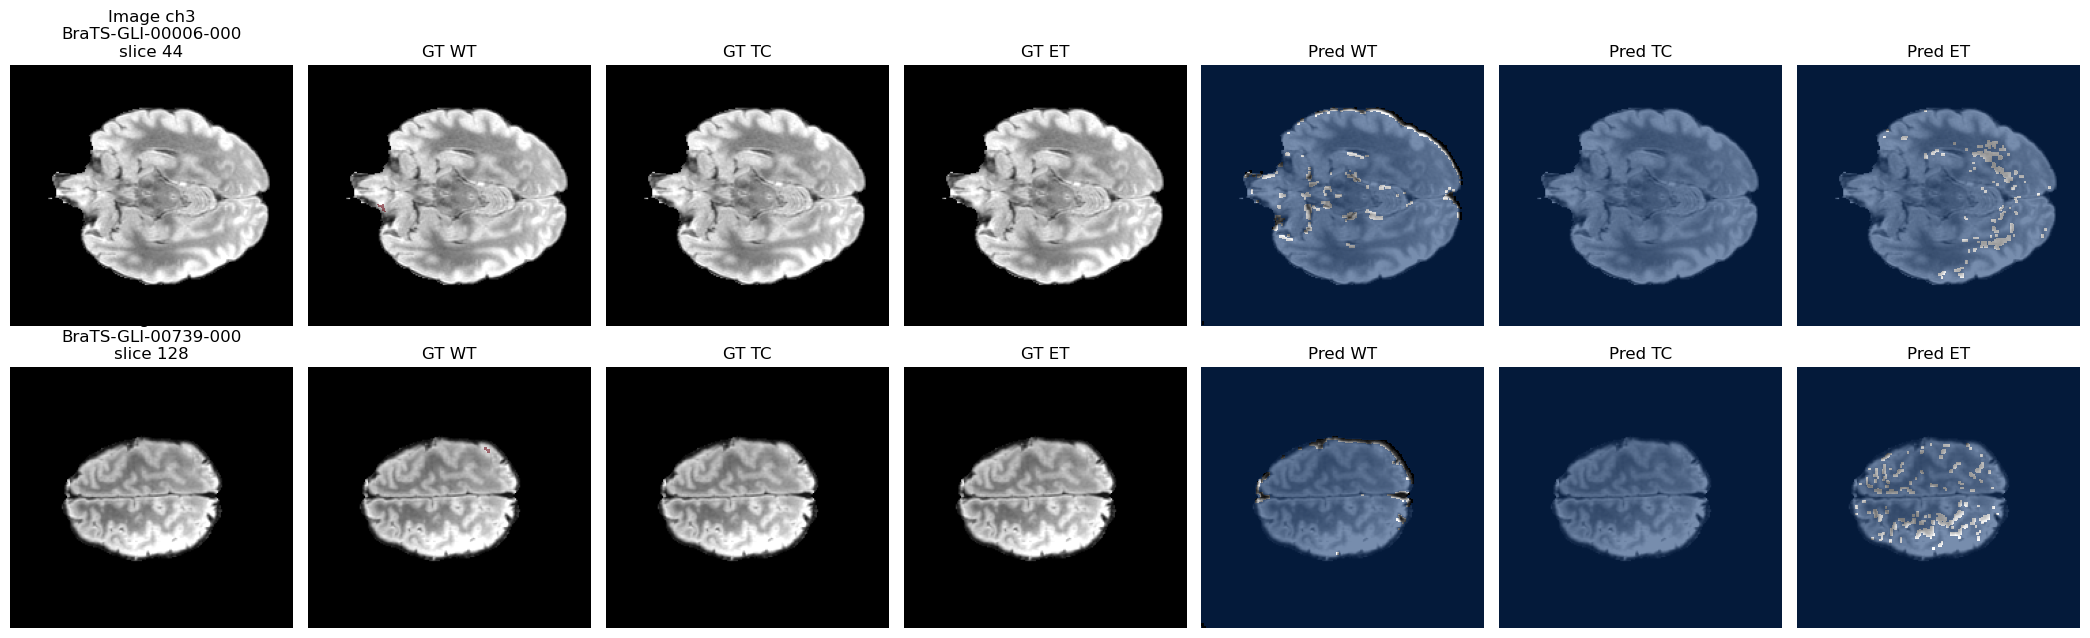

In [31]:
def normalize_mri_for_display(img, eps=1e-6):
    """
    Normalize MRI slice for visualization.

    Purpose:
    - Keep zero-valued background black.
    - Normalize only non-background pixels.
    - Use percentile clipping to improve contrast.

    Input:
        img: 2D numpy array

    Output:
        out: 2D numpy array in [0, 1]
    """
    img = img.astype(np.float32)

    # Treat values very close to zero as background.
    foreground_mask = np.abs(img) > eps

    out = np.zeros_like(img, dtype=np.float32)

    if foreground_mask.sum() == 0:
        return out

    foreground_values = img[foreground_mask]

    vmin = np.percentile(foreground_values, 1)
    vmax = np.percentile(foreground_values, 99)

    if vmax <= vmin:
        return out

    out[foreground_mask] = (img[foreground_mask] - vmin) / (vmax - vmin)
    out = np.clip(out, 0.0, 1.0)

    return out


@torch.no_grad()
def visualize_predictions(
    model,
    dataset,
    device,
    save_path,
    num_samples=3,
    image_channel=3,
    threshold=0.5,
):
    model.eval()

    indices = np.linspace(0, len(dataset) - 1, num_samples).astype(int)

    fig, axes = plt.subplots(
        num_samples,
        7,
        figsize=(21, 3.2 * num_samples),
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)
        label = sample["label"].numpy()

        logits = model(image_tensor)
        prob = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = sample["image"].numpy()
        bg = image_np[image_channel]

        # Normalize MRI for visualization and force background to black.
        bg_display = normalize_mri_for_display(bg)

        case_id = sample["case_id"]
        slice_idx = sample["slice_idx"]

        # ----------------------------------------------------
        # Column 0: MRI image
        # ----------------------------------------------------
        axes[row, 0].imshow(
            bg_display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, 0].set_title(
            f"Image ch{image_channel}\n{case_id}\nslice {slice_idx}"
        )
        axes[row, 0].axis("off")

        # ----------------------------------------------------
        # Columns 1-3: GT masks overlay on MRI
        # ----------------------------------------------------
        for c, name in enumerate(REGION_NAMES):
            axes[row, 1 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            gt_mask = np.ma.masked_where(label[c] <= 0.5, label[c])

            axes[row, 1 + c].imshow(
                gt_mask,
                cmap="Reds",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 1 + c].set_title(f"GT {name}")
            axes[row, 1 + c].axis("off")

        # ----------------------------------------------------
        # Columns 4-6: Prediction masks overlay on MRI
        # ----------------------------------------------------
        for c, name in enumerate(REGION_NAMES):
            axes[row, 4 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            pred_mask = np.ma.masked_where(pred[c] <= 0.5, pred[c])

            axes[row, 4 + c].imshow(
                pred_mask,
                cmap="Blues",
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 4 + c].set_title(f"Pred {name}")
            axes[row, 4 + c].axis("off")

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_before_training_black_bg_overlay.png",
    num_samples=2,
    image_channel=3,
    threshold=THRESHOLD,
)

## 14. Main Training Loop

This cell starts training.

It saves:

```text
outputs_task2_unet2d/
├── best_model.pth
├── last_model.pth
├── logs.csv
├── prediction_before_training.png
├── prediction_epoch_xxx.png
The best model is selected by validation mean Dice.

In [32]:
log_path = OUTPUT_DIR / "logs.csv"
best_model_path = OUTPUT_DIR / "best_model.pth"
last_model_path = OUTPUT_DIR / "last_model.pth"

# If True, load last_model.pth and continue training.
RESUME_TRAINING = True

# This means total target epochs, not additional epochs.
# Example:
#   If you already trained 50 epochs and set TOTAL_EPOCHS = 80,
#   it will continue from epoch 51 to epoch 80.
TOTAL_EPOCHS = 80

RESUME_CHECKPOINT_PATH = last_model_path

start_epoch = 1
best_mean_dice = -1.0
history = []


def get_best_mean_dice_from_log(log_path):
    if not Path(log_path).exists():
        return -1.0

    best_value = -1.0

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            if "mean_dice" in row:
                try:
                    value = float(row["mean_dice"])
                    best_value = max(best_value, value)
                except ValueError:
                    pass

    return best_value


if RESUME_TRAINING and RESUME_CHECKPOINT_PATH.exists():
    print("Resuming training from checkpoint:")
    print(RESUME_CHECKPOINT_PATH)

    checkpoint = torch.load(
        RESUME_CHECKPOINT_PATH,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    checkpoint_epoch = int(checkpoint["epoch"])
    start_epoch = checkpoint_epoch + 1

    best_mean_dice = float(checkpoint.get("best_mean_dice", -1.0))

    # In case best_mean_dice in last_model.pth is slightly stale,
    # recover the best value from logs.csv.
    best_from_log = get_best_mean_dice_from_log(log_path)
    best_mean_dice = max(best_mean_dice, best_from_log)

    print(f"Checkpoint epoch: {checkpoint_epoch}")
    print(f"Resume from epoch: {start_epoch}")
    print(f"Current best mean Dice: {best_mean_dice:.4f}")

else:
    print("Starting training from scratch.")

    start_epoch = 1
    best_mean_dice = -1.0

    # Only create a new log file when training from scratch.
    with open(log_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)

        writer.writerow(
            [
                "epoch",
                "lr",
                "train_loss",
                "train_dice_loss",
                "train_bce_loss",
                "val_loss",
                "val_dice_loss",
                "val_bce_loss",
                "dice_wt",
                "dice_tc",
                "dice_et",
                "mean_dice",
            ]
        )


if start_epoch > TOTAL_EPOCHS:
    print(
        f"Checkpoint epoch is already {start_epoch - 1}, "
        f"which is >= TOTAL_EPOCHS={TOTAL_EPOCHS}."
    )
    print("No further training will be performed.")

else:
    start_time = time.time()

    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
        print("=" * 80)
        print(f"Epoch {epoch}/{TOTAL_EPOCHS}")
        print("=" * 80)

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            scaler=scaler,
        )

        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            threshold=THRESHOLD,
        )

        scheduler.step(val_metrics["mean_dice"])

        lr = get_current_lr(optimizer)

        row = {
            "epoch": epoch,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_dice_loss": train_metrics["dice_loss"],
            "train_bce_loss": train_metrics["bce_loss"],
            "val_loss": val_metrics["loss"],
            "val_dice_loss": val_metrics["dice_loss"],
            "val_bce_loss": val_metrics["bce_loss"],
            "dice_wt": val_metrics["dice_wt"],
            "dice_tc": val_metrics["dice_tc"],
            "dice_et": val_metrics["dice_et"],
            "mean_dice": val_metrics["mean_dice"],
        }

        history.append(row)

        print(
            f"LR: {lr:.6e} | "
            f"Train Loss: {row['train_loss']:.4f} | "
            f"Val Loss: {row['val_loss']:.4f} | "
            f"Dice WT: {row['dice_wt']:.4f} | "
            f"Dice TC: {row['dice_tc']:.4f} | "
            f"Dice ET: {row['dice_et']:.4f} | "
            f"Mean Dice: {row['mean_dice']:.4f}"
        )

        # Append to logs.csv instead of overwriting it.
        with open(log_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)

            writer.writerow(
                [
                    row["epoch"],
                    row["lr"],
                    row["train_loss"],
                    row["train_dice_loss"],
                    row["train_bce_loss"],
                    row["val_loss"],
                    row["val_dice_loss"],
                    row["val_bce_loss"],
                    row["dice_wt"],
                    row["dice_tc"],
                    row["dice_et"],
                    row["mean_dice"],
                ]
            )

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_mean_dice": best_mean_dice,
            "config": {
                "in_channels": IN_CHANNELS,
                "out_channels": OUT_CHANNELS,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
                "threshold": THRESHOLD,
            },
        }

        # Save latest checkpoint.
        torch.save(checkpoint, last_model_path)

        # Save best checkpoint.
        if row["mean_dice"] > best_mean_dice:
            best_mean_dice = row["mean_dice"]
            checkpoint["best_mean_dice"] = best_mean_dice

            torch.save(checkpoint, best_model_path)

            print(f"Saved new best model. Mean Dice = {best_mean_dice:.4f}")

        if epoch % VIS_EVERY_N_EPOCHS == 0 or epoch == TOTAL_EPOCHS:
            visualize_predictions(
                model=model,
                dataset=val_dataset,
                device=DEVICE,
                save_path=OUTPUT_DIR / f"prediction_epoch_{epoch:03d}.png",
                num_samples=3,
                image_channel=3,
                threshold=THRESHOLD,
            )

    elapsed = time.time() - start_time

    print()
    print("Training finished.")
    print(f"Best Mean Dice: {best_mean_dice:.4f}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print("Best model:", best_model_path)
    print("Last model:", last_model_path)
    print("Logs:", log_path)


Resuming training from checkpoint:
outputs_task2_unet2d\last_model.pth
Checkpoint epoch: 80
Resume from epoch: 81
Current best mean Dice: 0.9394
Checkpoint epoch is already 80, which is >= TOTAL_EPOCHS=80.
No further training will be performed.


C:\Users\27871\AppData\Local\Temp\ipykernel_5384\3964579165.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## 15. Plot Training Curves

This cell plots:

- training loss
- validation loss
- Dice WT
- Dice TC
- Dice ET
- mean Dice

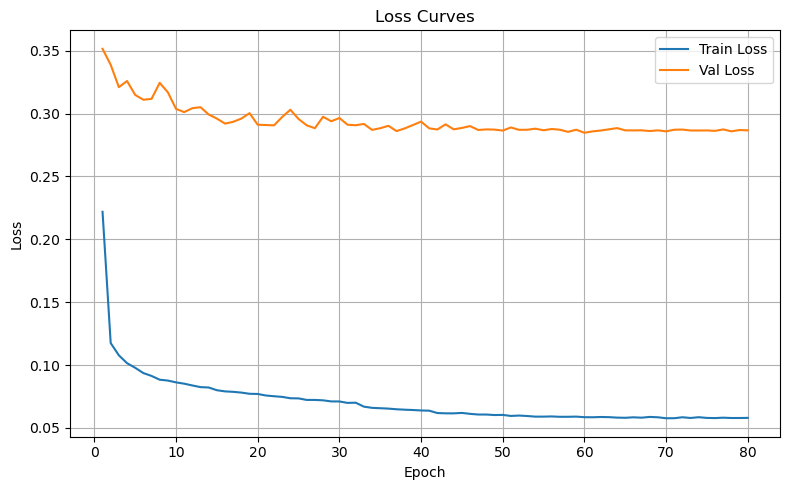

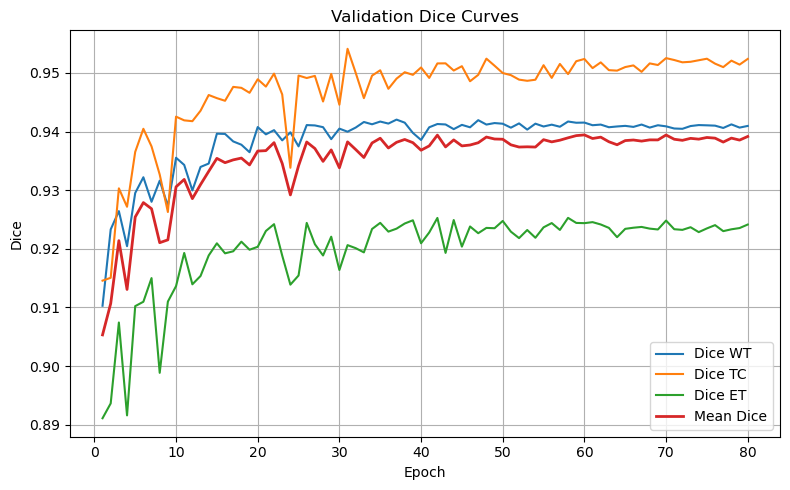

Best epoch log:
{'epoch': 60.0, 'lr': 3.125e-05, 'train_loss': 0.058522933143452506, 'train_dice_loss': 0.0516614730539045, 'train_bce_loss': 0.0068614601290949975, 'val_loss': 0.28478518073205594, 'val_dice_loss': 0.27407567386977794, 'val_bce_loss': 0.010709507011594283, 'dice_wt': 0.9415249734419806, 'dice_tc': 0.9523742382515565, 'dice_et': 0.9243741146302671, 'mean_dice': 0.9394244421079346}


In [33]:
def load_logs(log_path):
    rows = []

    with open(log_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})

    return rows


logs = load_logs(log_path)

epochs = [r["epoch"] for r in logs]

train_loss = [r["train_loss"] for r in logs]
val_loss = [r["val_loss"] for r in logs]

dice_wt = [r["dice_wt"] for r in logs]
dice_tc = [r["dice_tc"] for r in logs]
dice_et = [r["dice_et"] for r in logs]
mean_dice = [r["mean_dice"] for r in logs]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, dice_wt, label="Dice WT")
plt.plot(epochs, dice_tc, label="Dice TC")
plt.plot(epochs, dice_et, label="Dice ET")
plt.plot(epochs, mean_dice, label="Mean Dice", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dice_curve.png", dpi=150)
plt.show()

best_idx = int(np.argmax(mean_dice))

print("Best epoch log:")
print(logs[best_idx])

## 16. Load Best Model and Visualize Final Predictions

Use this cell after training.

It loads `best_model.pth` and generates final validation prediction maps.

Loaded best model from epoch: 60
Best Mean Dice: 0.9394244421079346


C:\Users\27871\AppData\Local\Temp\ipykernel_5384\4067538204.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(


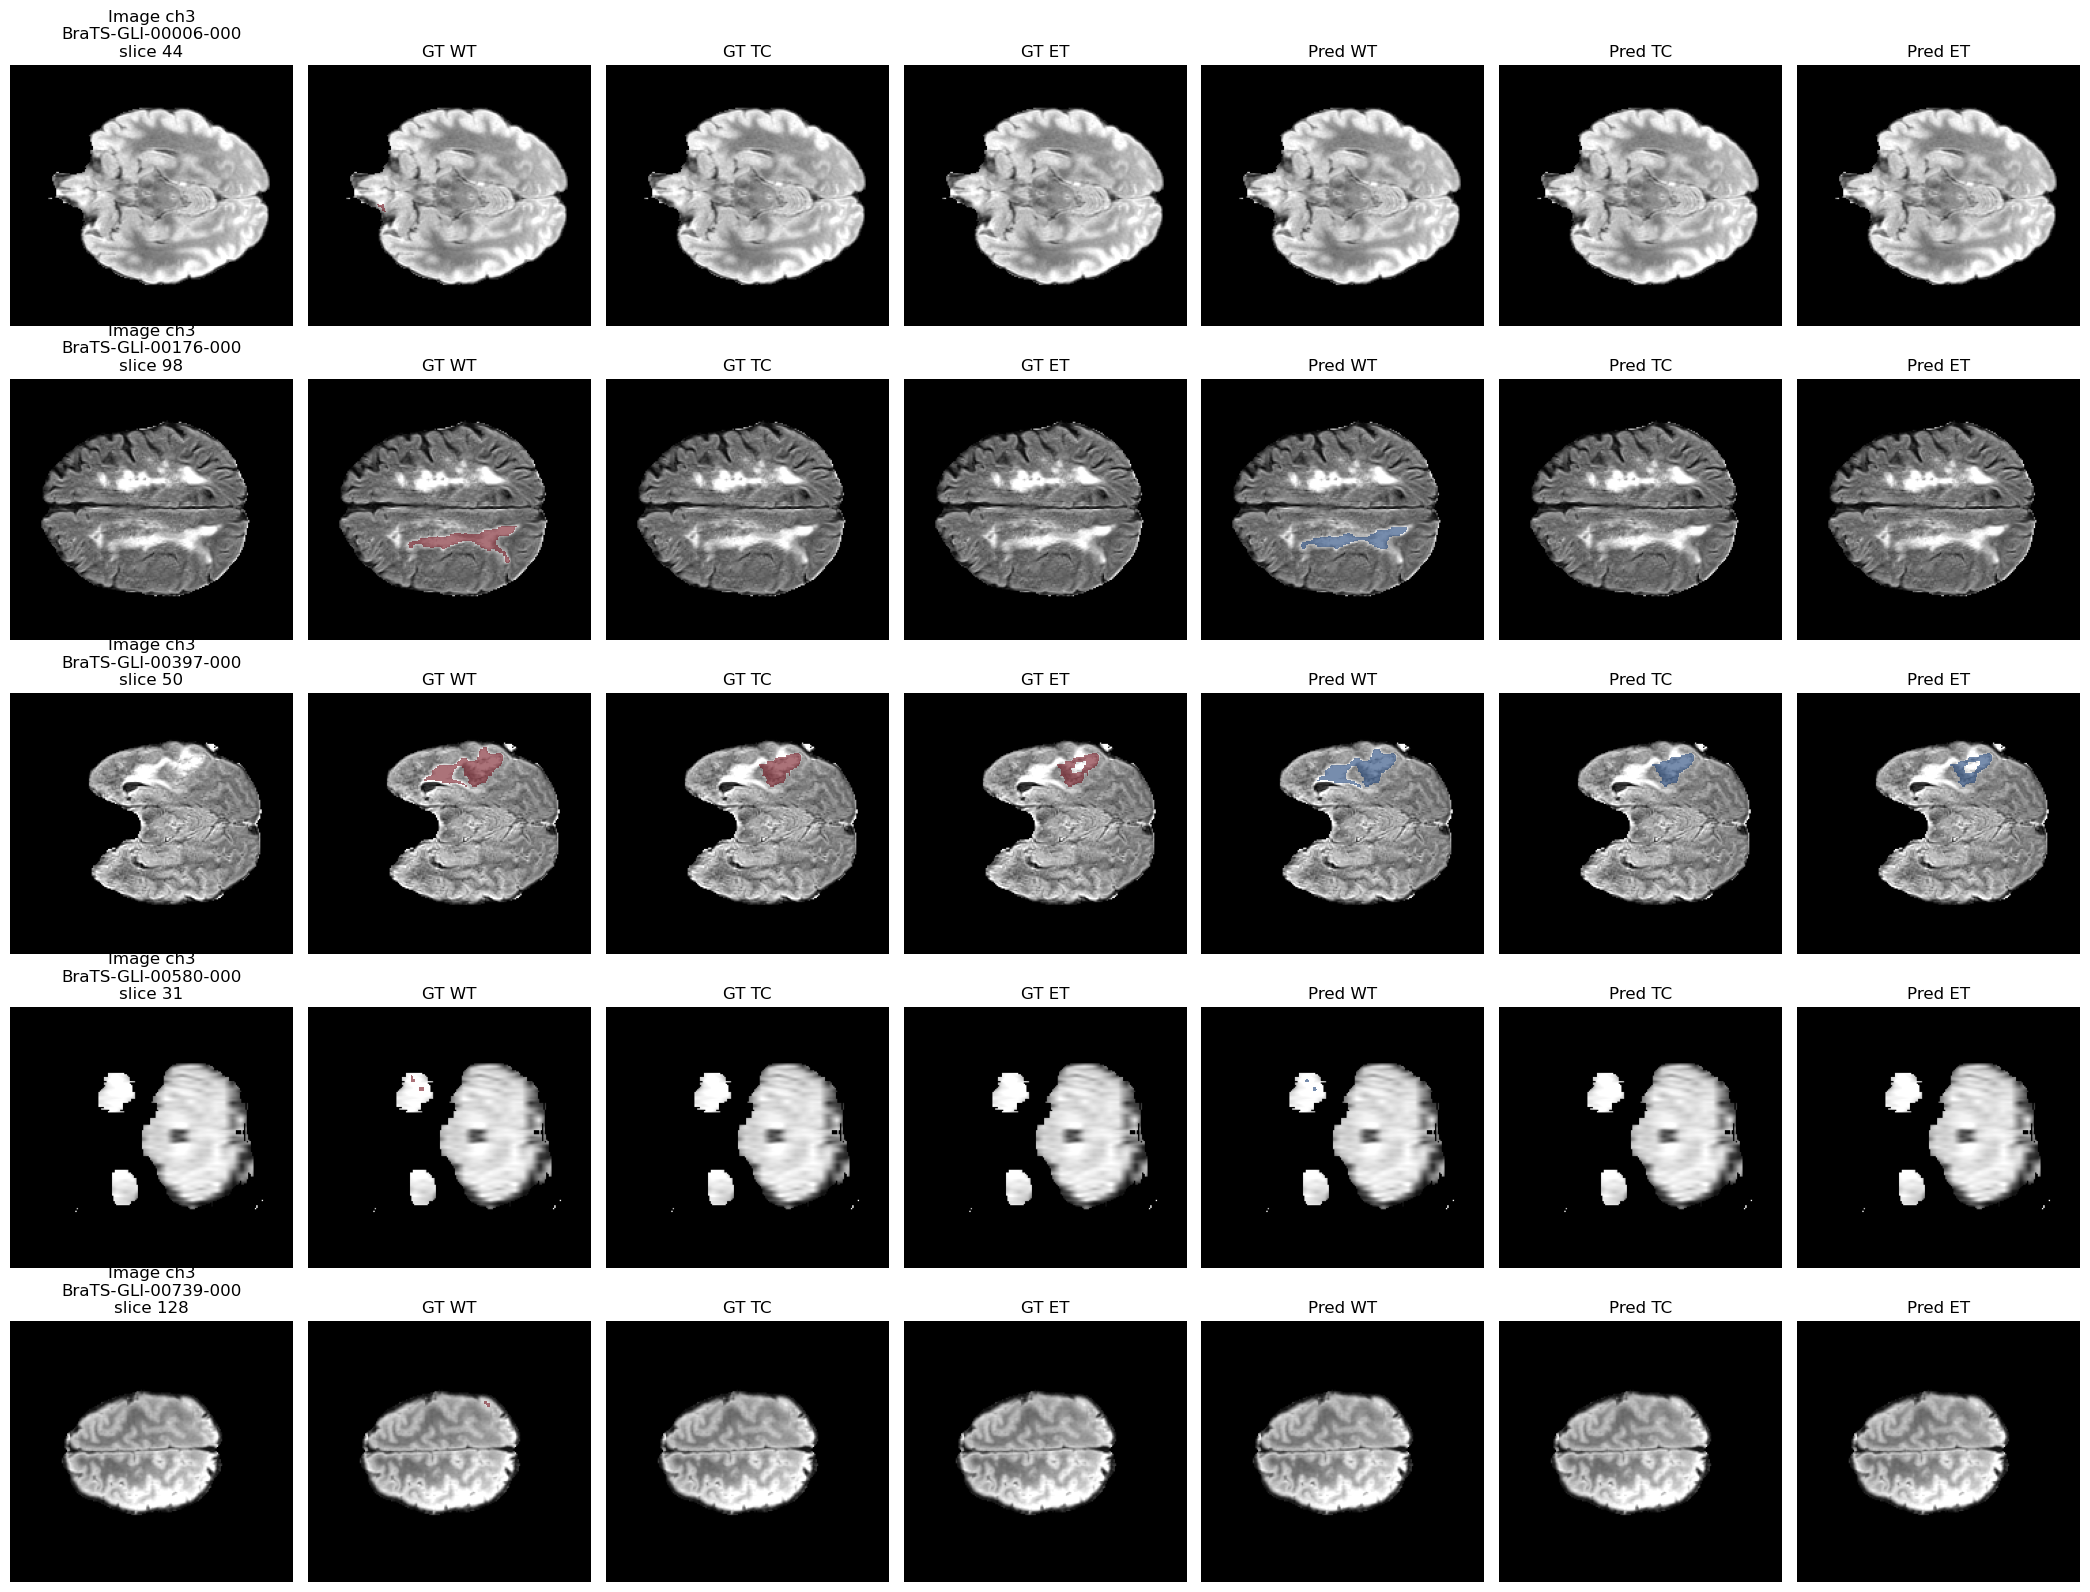

In [34]:
best_checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from epoch:", best_checkpoint["epoch"])
print("Best Mean Dice:", best_checkpoint["best_mean_dice"])

visualize_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    save_path=OUTPUT_DIR / "prediction_best_model.png",
    num_samples=5,
    image_channel=3,
    threshold=THRESHOLD,
)

Loading best model
Best model path: outputs_task2_unet2d\best_model.pth
Best model loaded successfully.

Searching all validation slices
Constraint: dice_wt != 1, dice_tc != 1, dice_et != 1


C:\Users\27871\AppData\Local\Temp\ipykernel_5384\762921240.py:178: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Total slices in dataset: 7749
Excluded slices: 2742
Valid candidate slices: 5007

Selected top 5 slices
Rank 1: case_id=BraTS-GLI-00413-000, slice_idx=106, WT=0.989480, TC=0.997854, ET=0.997792, Mean=0.995042
Rank 2: case_id=BraTS-GLI-00413-000, slice_idx=105, WT=0.991546, TC=0.995206, ET=0.995910, Mean=0.994221
Rank 3: case_id=BraTS-GLI-00413-000, slice_idx=103, WT=0.988082, TC=0.997632, ET=0.995701, Mean=0.993805
Rank 4: case_id=BraTS-GLI-00413-000, slice_idx=101, WT=0.990440, TC=0.995222, ET=0.993177, Mean=0.992946
Rank 5: case_id=BraTS-GLI-00413-000, slice_idx=99, WT=0.990785, TC=0.997018, ET=0.990747, Mean=0.992850



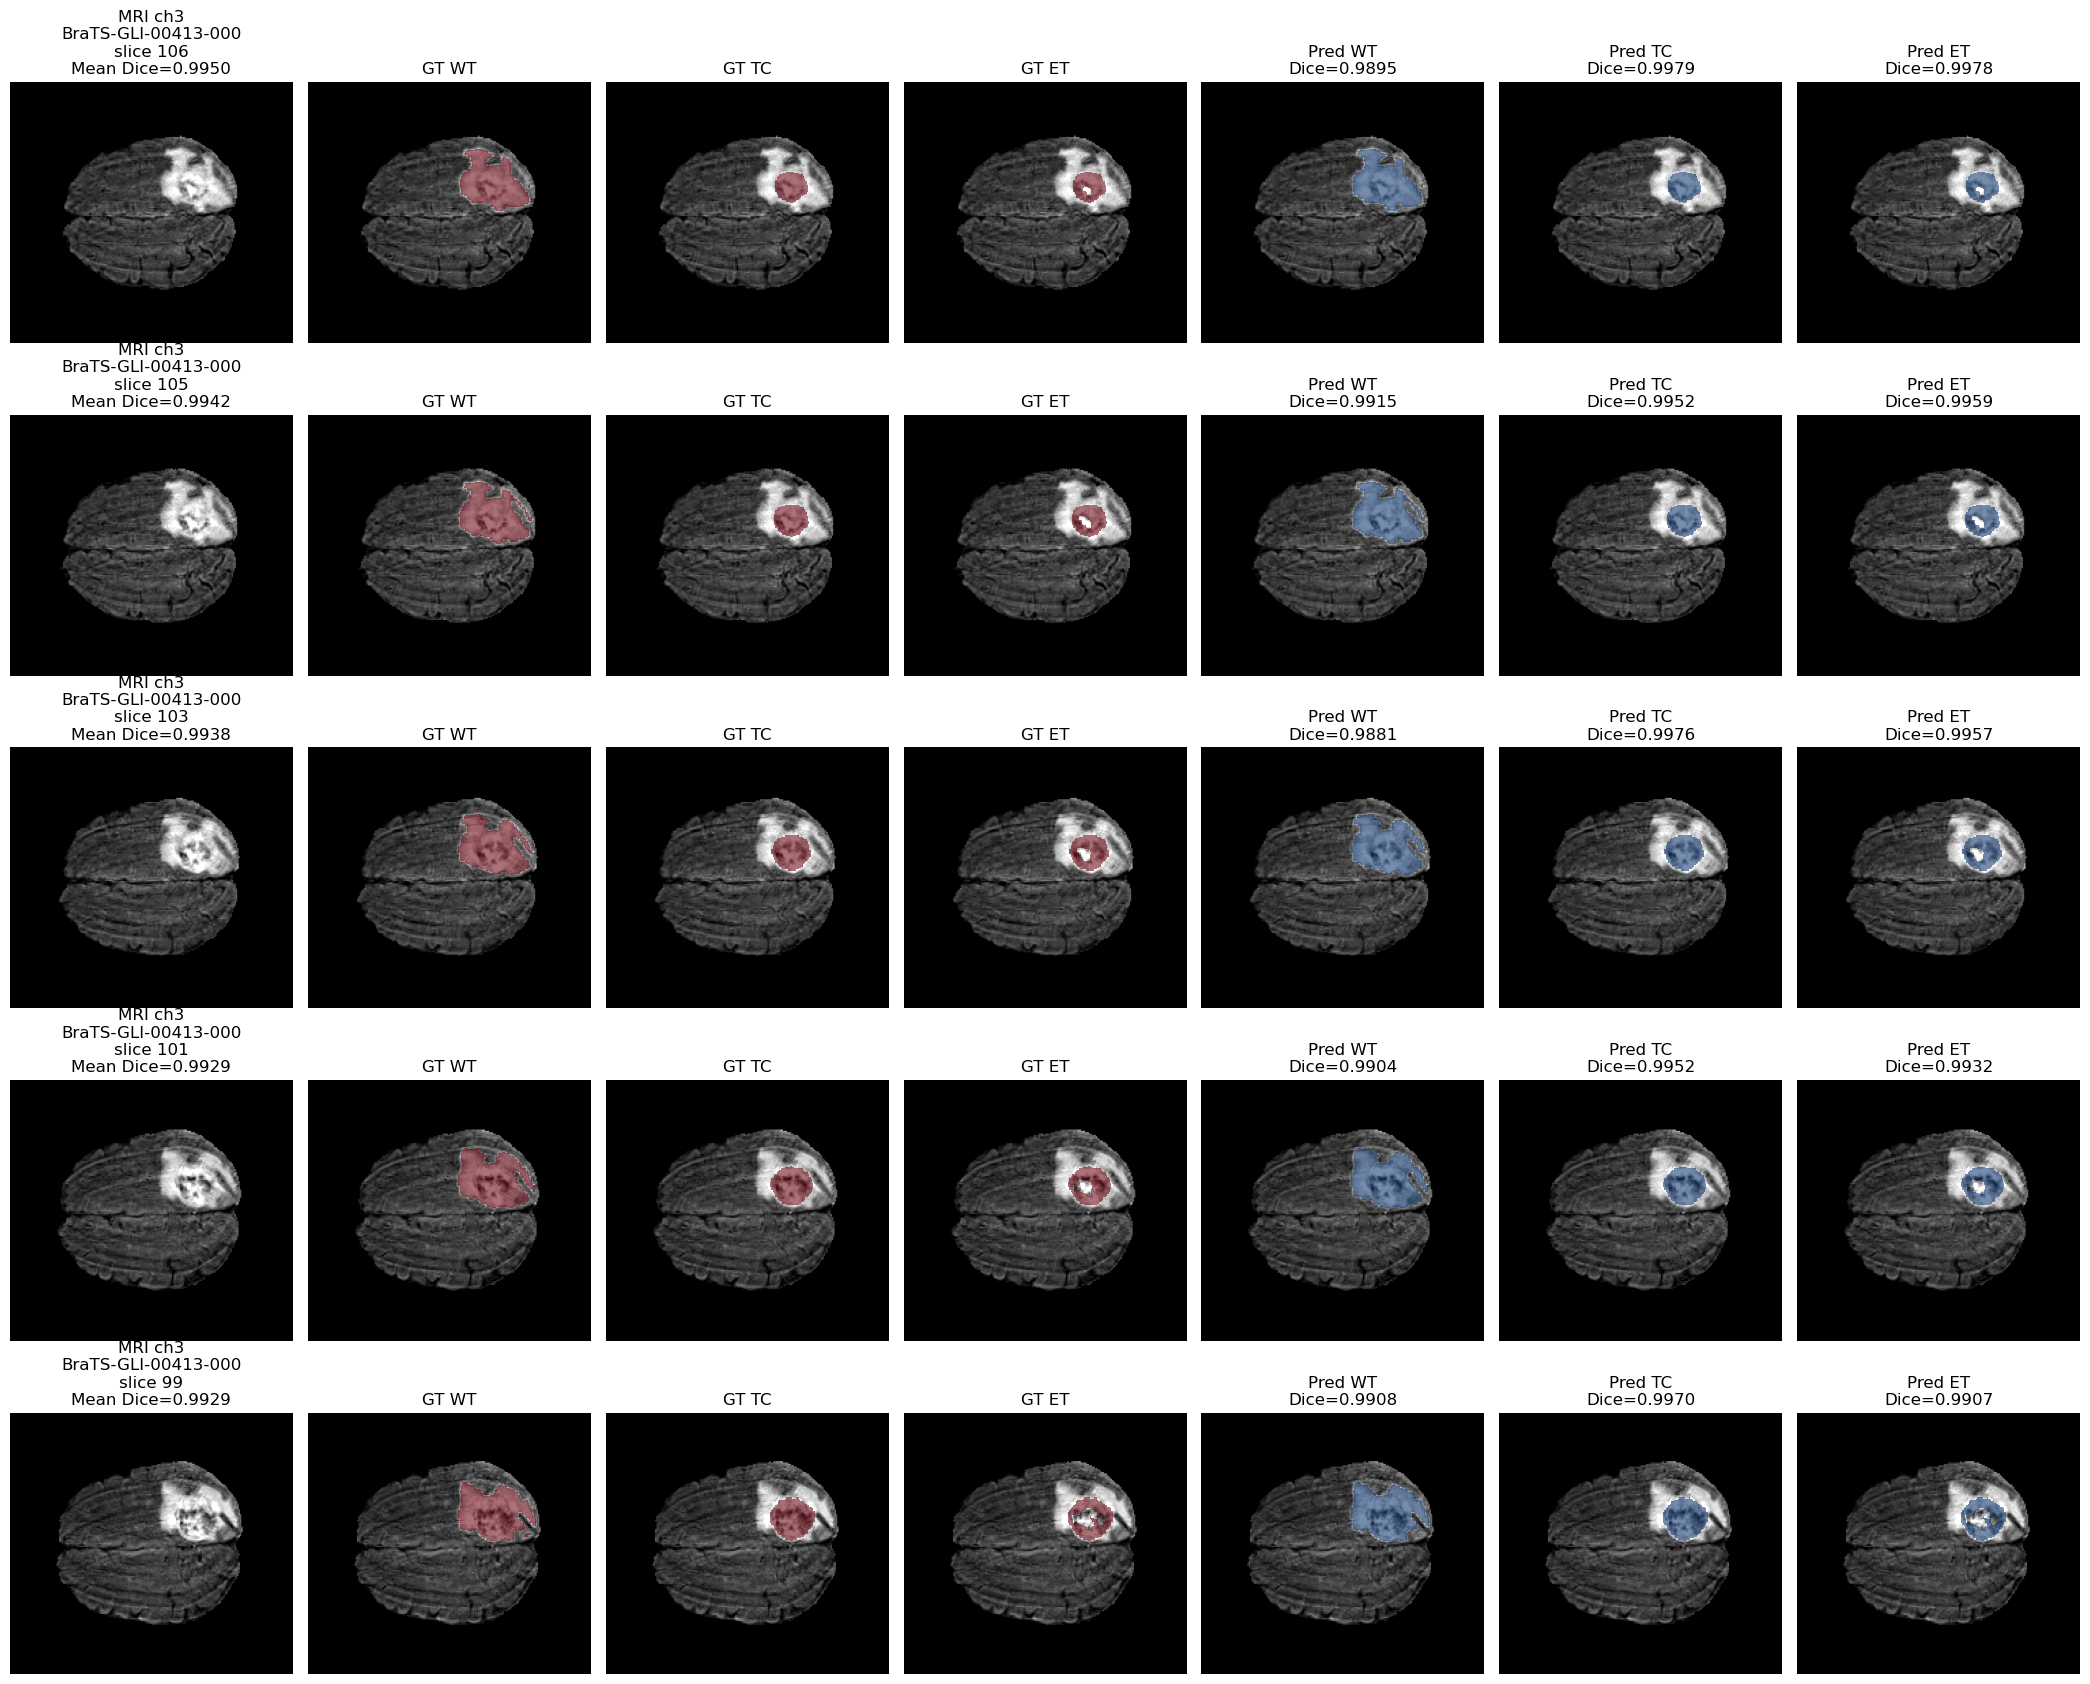

Saved visualization to: D:\Imaging\project2\outputs_task2_unet2d\best_model_top5_full_slices_dice_not_equal_1_overlay.png


In [35]:
# ============================================================
# Load Best Model and Visualize Final Predictions
# Full-slice search, select best 5 slices where:
# dice_wt != 1, dice_tc != 1, dice_et != 1
#
# Layout:
# MRI | GT WT | GT TC | GT ET | Pred WT | Pred TC | Pred ET
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

VIS_DATASET = val_dataset

TOP_K = 5
IMAGE_CHANNEL = 3

if "THRESHOLD" in globals():
    VIS_THRESHOLD = THRESHOLD
else:
    VIS_THRESHOLD = 0.5

DICE_ONE_EPS = 1e-7

SAVE_PATH = OUTPUT_DIR / "best_model_top5_full_slices_dice_not_equal_1_overlay.png"

if "best_model_path" in globals():
    BEST_MODEL_PATH = Path(best_model_path)
else:
    BEST_MODEL_PATH = OUTPUT_DIR / "best_model.pth"


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def to_python_value(x):
    if torch.is_tensor(x):
        if x.numel() == 1:
            return x.item()
        return x.detach().cpu().numpy().tolist()

    if isinstance(x, np.ndarray):
        if x.shape == ():
            return x.item()
        return x.tolist()

    return x


def estimate_background_value_from_corners(img):
    """
    Estimate MRI background / padding value from four corners.

    For your processed data, background is not necessarily 0.
    It is usually equal to a negative normalized value.
    """
    h, w = img.shape

    corner_values = np.array(
        [
            img[0, 0],
            img[0, w - 1],
            img[h - 1, 0],
            img[h - 1, w - 1],
        ],
        dtype=np.float32,
    )

    background_value = float(np.median(corner_values))

    return background_value


def normalize_mri_for_display_with_background(img, eps=1e-6):
    """
    Normalize MRI slice for visualization only.

    - Estimate background value from image corners.
    - Force background to black.
    - Normalize foreground using percentile clipping.
    """
    img = img.astype(np.float32)

    background_value = estimate_background_value_from_corners(img)

    foreground_mask = np.abs(img - background_value) > eps

    out = np.zeros_like(img, dtype=np.float32)

    if foreground_mask.sum() == 0:
        return out

    foreground_values = img[foreground_mask]

    vmin = np.percentile(foreground_values, 1)
    vmax = np.percentile(foreground_values, 99)

    if vmax <= vmin:
        return out

    out[foreground_mask] = (img[foreground_mask] - vmin) / (vmax - vmin)
    out = np.clip(out, 0.0, 1.0)

    return out


def compute_hard_dice_per_channel(pred, target, eps=1e-7):
    """
    pred:   numpy array, shape [3, H, W], binary 0/1
    target: numpy array, shape [3, H, W], binary 0/1

    Returns:
        dice_per_channel: numpy array, shape [3]
        mean_dice: float
    """
    dice_scores = []

    for c in range(target.shape[0]):
        pred_c = pred[c].astype(bool)
        target_c = target[c].astype(bool)

        pred_sum = pred_c.sum()
        target_sum = target_c.sum()

        if pred_sum + target_sum == 0:
            dice = 1.0
        else:
            intersection = np.logical_and(pred_c, target_c).sum()
            dice = (2.0 * intersection + eps) / (
                pred_sum + target_sum + eps
            )

        dice_scores.append(float(dice))

    dice_scores = np.array(dice_scores, dtype=np.float32)
    mean_dice = float(dice_scores.mean())

    return dice_scores, mean_dice


def get_sample_arrays(sample):
    image = sample["image"]
    label = sample["label"]

    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
    else:
        image_np = np.asarray(image)

    if torch.is_tensor(label):
        label_np = label.detach().cpu().numpy()
    else:
        label_np = np.asarray(label)

    case_id = to_python_value(sample["case_id"])
    slice_idx = int(to_python_value(sample["slice_idx"]))

    return image_np, label_np, case_id, slice_idx


# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

print("=" * 80)
print("Loading best model")
print("=" * 80)
print("Best model path:", BEST_MODEL_PATH)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()

print("Best model loaded successfully.")
print()


# ------------------------------------------------------------
# Rank all validation slices by hard mean Dice
# Constraint:
# dice_wt < 1, dice_tc < 1, dice_et < 1
# ------------------------------------------------------------

@torch.no_grad()
def rank_best_slices_full_range_dice_not_equal_one(
    model,
    dataset,
    device,
    threshold=0.5,
    dice_one_eps=1e-7,
):
    model.eval()

    candidates = []
    excluded_equal_one = 0

    print("=" * 80)
    print("Searching all validation slices")
    print("Constraint: dice_wt != 1, dice_tc != 1, dice_et != 1")
    print("=" * 80)

    for idx in range(len(dataset)):
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)
        label_np = sample["label"].detach().cpu().numpy()

        logits = model(image_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred_np = (probs > threshold).astype(np.uint8)

        dice_per_channel, mean_dice = compute_hard_dice_per_channel(
            pred=pred_np,
            target=label_np,
        )

        dice_wt = float(dice_per_channel[0])
        dice_tc = float(dice_per_channel[1])
        dice_et = float(dice_per_channel[2])

        # Strict condition:
        # all three label dice values must be different from 1.
        # Floating-safe version:
        valid = (
            dice_wt < 1.0 - dice_one_eps
            and dice_tc < 1.0 - dice_one_eps
            and dice_et < 1.0 - dice_one_eps
        )

        if not valid:
            excluded_equal_one += 1
            continue

        case_id = to_python_value(sample["case_id"])
        slice_idx = int(to_python_value(sample["slice_idx"]))

        candidates.append(
            {
                "dataset_idx": idx,
                "case_id": case_id,
                "slice_idx": slice_idx,
                "dice_wt": dice_wt,
                "dice_tc": dice_tc,
                "dice_et": dice_et,
                "mean_dice": float(mean_dice),
            }
        )

    if len(candidates) == 0:
        raise RuntimeError(
            "No valid candidate slices found. "
            "All slices were excluded because at least one of "
            "dice_wt, dice_tc, dice_et was equal or extremely close to 1."
        )

    candidates = sorted(
        candidates,
        key=lambda x: x["mean_dice"],
        reverse=True,
    )

    print(f"Total slices in dataset: {len(dataset)}")
    print(f"Excluded slices: {excluded_equal_one}")
    print(f"Valid candidate slices: {len(candidates)}")
    print()

    return candidates


ranked_candidates = rank_best_slices_full_range_dice_not_equal_one(
    model=model,
    dataset=VIS_DATASET,
    device=DEVICE,
    threshold=VIS_THRESHOLD,
    dice_one_eps=DICE_ONE_EPS,
)

top_candidates = ranked_candidates[:TOP_K]

print("=" * 80)
print(f"Selected top {len(top_candidates)} slices")
print("=" * 80)

for i, item in enumerate(top_candidates, start=1):
    print(
        f"Rank {i}: "
        f"case_id={item['case_id']}, "
        f"slice_idx={item['slice_idx']}, "
        f"WT={item['dice_wt']:.6f}, "
        f"TC={item['dice_tc']:.6f}, "
        f"ET={item['dice_et']:.6f}, "
        f"Mean={item['mean_dice']:.6f}"
    )

print()


# ------------------------------------------------------------
# Visualize selected top slices
# ------------------------------------------------------------

@torch.no_grad()
def visualize_top_slices_overlay(
    model,
    dataset,
    selected_items,
    device,
    save_path,
    image_channel=3,
    threshold=0.5,
):
    model.eval()

    num_samples = len(selected_items)

    fig, axes = plt.subplots(
        num_samples,
        7,
        figsize=(21, 3.4 * num_samples),
    )

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    red_cmap = plt.cm.Reds.copy()
    red_cmap.set_bad(color=(0, 0, 0, 0))

    blue_cmap = plt.cm.Blues.copy()
    blue_cmap.set_bad(color=(0, 0, 0, 0))

    region_names = REGION_NAMES if "REGION_NAMES" in globals() else ["WT", "TC", "ET"]

    for row, item in enumerate(selected_items):
        idx = item["dataset_idx"]
        sample = dataset[idx]

        image_tensor = sample["image"].unsqueeze(0).to(device)

        image_np, label_np, case_id, slice_idx = get_sample_arrays(sample)

        logits = model(image_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
        pred_np = (probs > threshold).astype(np.uint8)

        bg = image_np[image_channel]
        bg_display = normalize_mri_for_display_with_background(bg)

        dice_wt = item["dice_wt"]
        dice_tc = item["dice_tc"]
        dice_et = item["dice_et"]
        mean_dice = item["mean_dice"]

        # ----------------------------------------------------
        # Column 0: MRI image
        # ----------------------------------------------------
        axes[row, 0].imshow(
            bg_display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        axes[row, 0].set_title(
            f"MRI ch{image_channel}\n"
            f"{case_id}\n"
            f"slice {slice_idx}\n"
            f"Mean Dice={mean_dice:.4f}"
        )
        axes[row, 0].axis("off")

        # ----------------------------------------------------
        # Columns 1-3: GT WT / TC / ET overlay
        # ----------------------------------------------------
        for c, name in enumerate(region_names):
            axes[row, 1 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            gt_mask = np.ma.masked_where(
                label_np[c] <= 0.5,
                label_np[c],
            )

            axes[row, 1 + c].imshow(
                gt_mask,
                cmap=red_cmap,
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 1 + c].set_title(f"GT {name}")
            axes[row, 1 + c].axis("off")

        # ----------------------------------------------------
        # Columns 4-6: Pred WT / TC / ET overlay
        # ----------------------------------------------------
        dice_values = [dice_wt, dice_tc, dice_et]

        for c, name in enumerate(region_names):
            axes[row, 4 + c].imshow(
                bg_display,
                cmap="gray",
                vmin=0,
                vmax=1,
            )

            pred_mask = np.ma.masked_where(
                pred_np[c] <= 0.5,
                pred_np[c],
            )

            axes[row, 4 + c].imshow(
                pred_mask,
                cmap=blue_cmap,
                alpha=0.55,
                vmin=0,
                vmax=1,
            )

            axes[row, 4 + c].set_title(
                f"Pred {name}\nDice={dice_values[c]:.4f}"
            )
            axes[row, 4 + c].axis("off")

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved visualization to:", save_path.resolve())


visualize_top_slices_overlay(
    model=model,
    dataset=VIS_DATASET,
    selected_items=top_candidates,
    device=DEVICE,
    save_path=SAVE_PATH,
    image_channel=IMAGE_CHANNEL,
    threshold=VIS_THRESHOLD,
)

## 17. Notes for Report

You can describe this baseline as follows:

- Dataset: 595 cases, 38,976 2D slices
- Input: four-channel MRI image, shape `(4, 192, 208)`
- Label: three-channel binary mask, shape `(3, 192, 208)`
- Regions: WT, TC, ET
- Model: 2D U-Net
- Loss: Dice Loss + BCEWithLogitsLoss
- Optimizer: AdamW
- Scheduler: ReduceLROnPlateau
- Split: patient-level train/validation split
- Metrics: Dice WT, Dice TC, Dice ET, Mean Dice

Because WT, TC and ET are nested regions rather than mutually exclusive classes, this experiment formulates the task as multi-label segmentation and applies sigmoid activation to each output channel independently.
